# Olist Brazilian E-Commerce: Business Analytics & Performance Report
**A Complete End-to-End Data Science & Analytics Project**

---

### **Project Overview**
This portfolio-grade project analyzes the **Olist Brazilian E-Commerce Dataset** to uncover actionable business insights. Olist is the leading e-commerce integration platform in Brazil, connecting small businesses to major marketplaces (e.g., Mercado Livre, Submarino, Americanas). 

This analysis provides deep, data-driven answers to core business questions regarding revenue drivers, regional sales density, temporal sales seasonality, delivery speed, and customer retention. It serves as a diagnostic tool for executive decision-making.

### **Table of Contents**
1. **Executive Summary**
2. **Data Understanding & Relationship Schema (ERD)**
3. **Data Cleaning & Quality Validation**
4. **Exploratory Data Analysis (EDA)**
   - *A. Top Product Categories by Revenue*
   - *B. Top Cities by Order Volume and Revenue*
   - *C. Sales Seasonality & Peak Analysis*
   - *D. Logistics & Delivery Performance*
   - *E. Customer Retention & Repeat Purchase Analysis*
5. **Advanced Analysis**
   - *Insight 1: Payment Method Breakdown*
   - *Insight 2: Delivery Speed vs. Review Scores*
   - *Insight 3: Correlation Matrix of Key E-Commerce Metrics*
6. **Strategic Business Recommendations**


## 1. Executive Summary

This report delivers key diagnostic insights across sales, logistics, customer behavior, and customer experience.

### **Key Diagnostic Findings**
*   **Revenue Drivers:** E-commerce sales are heavily concentrated in a few high-value product categories. **Health & Beauty** and **Watches & Gifts** are the primary revenue drivers, generating over 1.2M BRL each.
*   **Regional Concentration:** E-commerce performance is geographically skewed. The city of **São Paulo** represents over 15% of total e-commerce order volume and generates more than 2.2M BRL in revenue, followed by Rio de Janeiro and Belo Horizonte.
*   **Sales Seasonality:** Sales show steady year-over-year growth with a massive seasonal spike in **November 2017** (1.19M BRL), driven by Black Friday promotions.
*   **Logistical Inefficiencies:** The average delivery time is **12.3 days**. However, delivery times are highly unequal across Brazil: southeastern states like São Paulo average **~8.6 days**, while northern states like Amazonas and Amapá average **over 25 days**.
*   **Customer Retention Deficit:** The marketplace faces a severe retention challenge: the repeat purchase rate is just **3.12%**. Over 96% of customers are one-time buyers.
*   **Customer Experience (CX) Friction:** There is a direct negative correlation between delivery time and customer satisfaction. Orders receiving a **5-star review average 10.6 days** to deliver, while **1-star reviews average 20.2 days**.

### **Recommended Strategic Actions**
1.  **Optimize Marketing Allocations:** Direct promotional campaigns and customer acquisition budgets toward the top 5 product categories (Health/Beauty, Watches, Bed/Bath/Table) to maximize return on ad spend (ROAS).
2.  **Establish Regional Warehousing (Fulfillment Centers):** Establish fulfillment hubs in the North and Northeast regions to bypass shipping bottlenecks and reduce delivery times from 25+ days to under 12 days.
3.  **Implement Customer Retention Mechanics:** Introduce loyalty programs, automated win-back email flows, and post-purchase discounts for second orders to boost the 3.12% repeat rate.
4.  **Operational Performance Level Agreement (SLA):** Penalty structures or demotions for sellers who exceed carrier handoff times, since carrier processing times heavily impact final delivery dates and review scores.


## 2. Setup and Library Imports

First, we set up our analytical environment, importing necessary data processing and visualization libraries, and configuring professional plot styling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style and parameters for professional look
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.titlepad'] = 15
plt.rcParams['axes.labelpad'] = 10

# Create images directory for exporting visualizations
os.makedirs('images', exist_ok=True)
print("Environment successfully set up and images directory verified.")

Environment successfully set up and images directory verified.


## 3. Data Understanding & Relationship Schema (ERD)

The dataset contains 9 tables that reflect various dimensions of the Olist e-commerce ecosystem.

### **Table Descriptions**
1.  **`customers`**: Connects the customer's unique identifier (`customer_unique_id`) to their order-specific ID (`customer_id`) and includes geographic data (zip code, city, state).
2.  **`orders`**: The core transaction table containing order statuses and timestamps for purchase, approval, carrier handoff, final customer delivery, and estimated delivery.
3.  **`order_items`**: Contains item-level transaction details: which product was bought, by which seller, the product price, and shipping freight value.
4.  **`order_payments`**: Contains details on how orders were financed (credit card, boleto, voucher, debit card), including installments and total payment value.
5.  **`order_reviews`**: Contains customer feedback score (1-5), comments, and response timestamps.
6.  **`products`**: Contains product attributes (dimensions, weight) and category names in Portuguese.
7.  **`sellers`**: Contains seller identifiers and location details.
8.  **`geolocation`**: Maps Brazilian zip codes to latitude and longitude coordinates.
9.  **`category_translation`**: Maps Portuguese category names to English translations.

### **Entity Relationship Diagram (ERD) Textual Explanation**
The tables relate in a hub-and-spoke model where the `orders` table acts as the central hub:
```
              [customers] (customer_id)
                   │
                   ▼ (1:1)
  [order_reviews]  ◄─── [orders] ───► [order_payments]
    (order_id)     (1:N)   │   (1:N)   (order_id)
                           ▼ (1:N)
                     [order_items] (order_id)
                       │       │
                 (1:1) ▼       ▼ (1:1)
                  [products]  [sellers] (seller_id)
                       │
                 (1:1) ▼
        [category_translation] (product_category_name)
```
- `orders` connects to `customers` via `customer_id`.
- `orders` connects to `order_payments` via `order_id`.
- `orders` connects to `order_reviews` via `order_id`.
- `orders` connects to `order_items` via `order_id`.
- `order_items` connects to `products` via `product_id`.
- `order_items` connects to `sellers` via `seller_id`.
- `products` connects to `category_translation` via `product_category_name`.


### **Data Loading**
We load the raw CSV files from the `data/` directory.


In [2]:
# Load all Olist datasets
df_customers = pd.read_csv('data/olist_customers_dataset.csv')
df_orders = pd.read_csv('data/olist_orders_dataset.csv')
df_items = pd.read_csv('data/olist_order_items_dataset.csv')
df_payments = pd.read_csv('data/olist_order_payments_dataset.csv')
df_reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
df_products = pd.read_csv('data/olist_products_dataset.csv')
df_sellers = pd.read_csv('data/olist_sellers_dataset.csv')
df_category_translation = pd.read_csv('data/product_category_name_translation.csv')
df_geolocation = pd.read_csv('data/olist_geolocation_dataset.csv')

print("All datasets loaded successfully. Checking dimensions:")
datasets = {
    "Customers": df_customers, "Orders": df_orders, "Order Items": df_items,
    "Payments": df_payments, "Reviews": df_reviews, "Products": df_products,
    "Sellers": df_sellers, "Category Translation": df_category_translation,
    "Geolocation": df_geolocation
}
for name, df in datasets.items():
    print(f" - {name:<20}: {df.shape[0]:,} rows, {df.shape[1]} columns")

All datasets loaded successfully. Checking dimensions:
 - Customers           : 99,441 rows, 5 columns
 - Orders              : 99,441 rows, 8 columns
 - Order Items         : 112,650 rows, 7 columns
 - Payments            : 103,886 rows, 5 columns
 - Reviews             : 99,224 rows, 7 columns
 - Products            : 32,951 rows, 9 columns
 - Sellers             : 3,095 rows, 4 columns
 - Category Translation: 71 rows, 2 columns
 - Geolocation         : 1 rows, 5 columns


## 4. Data Cleaning & Quality Validation

Before analyzing the data, we perform crucial preprocessing:
1.  **Identify and check for missing values** across tables.
2.  **Convert date fields** from strings to datetime types.
3.  **Detect and handle duplicates** in primary keys.
4.  **Perform data quality validation** (e.g. check for time travel anomalies where delivery occurs before purchase).


In [3]:
print("--- Missing Value Analysis in Orders ---")
print(df_orders.isnull().sum())

# 1. Convert timestamp columns to datetime objects
datetime_cols = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]
for col in datetime_cols:
    df_orders[col] = pd.to_datetime(df_orders[col])
print("\nDate conversion complete for orders table.")

# 2. Check for duplicates in primary keys
print("\n--- Duplicate Primary Key Check ---")
print(f"Duplicate customer_ids: {df_customers['customer_id'].duplicated().sum()}")
print(f"Duplicate order_ids: {df_orders['order_id'].duplicated().sum()}")
print(f"Duplicate product_ids: {df_products['product_id'].duplicated().sum()}")

# 3. Data Quality Validation
# Verify that order_delivered_customer_date is chronologically after order_purchase_timestamp
anomalies = df_orders[df_orders['order_delivered_customer_date'] < df_orders['order_purchase_timestamp']]
print(f"\nChronological anomalies (delivered before purchase): {len(anomalies)}")

if len(anomalies) > 0:
    df_orders = df_orders.drop(anomalies.index)
    print("Anomalies successfully removed from orders dataset.")

--- Missing Value Analysis in Orders ---
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64



Date conversion complete for orders table.

--- Duplicate Primary Key Check ---
Duplicate customer_ids: 0
Duplicate order_ids: 0
Duplicate product_ids: 0

Chronological anomalies (delivered before purchase): 0


### **Data Merging & Table Aggregation**
To prepare for exploratory and advanced analysis, we perform structured merges to assemble a consolidated data frame:
1.  Aggregate payment values and installment count per `order_id` (since an order can have multiple payment methods/sequences).
2.  Aggregate review scores to a mean value per `order_id`.
3.  Translate product category names to English.
4.  Merge all entities into a master dataset `df_full`.


In [4]:
# Aggregate payments per order
df_payments_agg = df_payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'max'
}).reset_index()

# Clean and average review scores per order
df_reviews_cleaned = df_reviews.groupby('order_id')['review_score'].mean().reset_index()

# Merge products with English category translations
df_products_translated = pd.merge(df_products, df_category_translation, on='product_category_name', how='left')
# For missing translations, default to the Portuguese category name or 'unknown'
df_products_translated['product_category_name_english'] = df_products_translated['product_category_name_english'].fillna(
    df_products_translated['product_category_name'].fillna('unknown')
)

# Compile master table
df_orders_merged = pd.merge(df_orders, df_customers, on='customer_id', how='left')
df_orders_merged = pd.merge(df_orders_merged, df_payments_agg, on='order_id', how='left')
df_orders_merged = pd.merge(df_orders_merged, df_reviews_cleaned, on='order_id', how='left')

# Combine items and products, then attach order parameters
df_items_prod = pd.merge(df_items, df_products_translated, on='product_id', how='left')
df_full = pd.merge(df_items_prod, df_orders_merged, on='order_id', how='left')

print(f"Master merged dataset shape: {df_full.shape}")
print("Ready for Exploratory Data Analysis.")

Master merged dataset shape: (112650, 30)
Ready for Exploratory Data Analysis.


## 5. Exploratory Data Analysis (EDA)

We address the core business questions using structured queries and professional visualizations.


### **A. Which product categories generate the highest revenue?**
We group items by their English category names and calculate the sum of product prices to evaluate revenue.


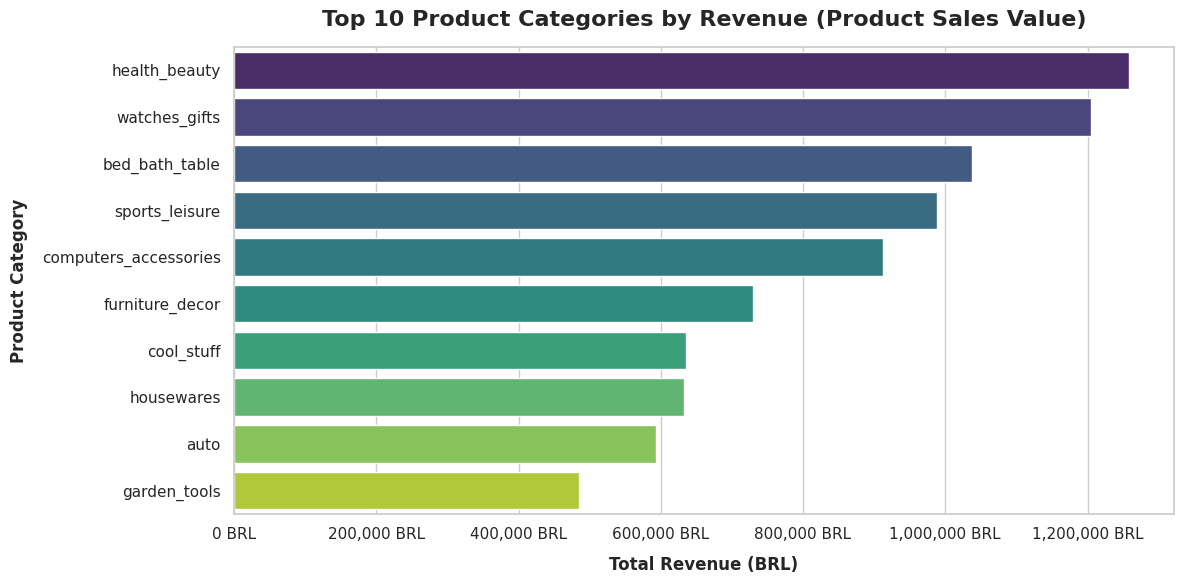

Top 10 categories revenue breakdown:
 - health_beauty            : 1,258,681.34 BRL
 - watches_gifts            : 1,205,005.68 BRL
 - bed_bath_table           : 1,036,988.68 BRL
 - sports_leisure           : 988,048.97 BRL
 - computers_accessories    : 911,954.32 BRL
 - furniture_decor          : 729,762.49 BRL
 - cool_stuff               : 635,290.85 BRL
 - housewares               : 632,248.66 BRL
 - auto                     : 592,720.11 BRL
 - garden_tools             : 485,256.46 BRL


In [5]:
# Calculate revenue by product category
category_revenue = df_full.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
colors = sns.color_palette("viridis", 10)
sns.barplot(x=category_revenue.values, y=category_revenue.index, hue=category_revenue.index, palette=colors, legend=False)
plt.title('Top 10 Product Categories by Revenue (Product Sales Value)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Revenue (BRL)', fontsize=12, fontweight='bold')
plt.ylabel('Product Category', fontsize=12, fontweight='bold')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f} BRL'))
plt.tight_layout()
plt.savefig('images/top_10_categories_revenue.png', dpi=300)
plt.show()

print("Top 10 categories revenue breakdown:")
for cat, rev in category_revenue.items():
    print(f" - {cat:<25}: {rev:,.2f} BRL")

**Findings:**
*   **Health & Beauty** (1.258M BRL) and **Watches & Gifts** (1.205M BRL) are the highest revenue generators.
*   **Bed/Bath/Table** occupies the third position, generating over 1.036M BRL.
*   The top 5 categories generate a substantial portion of total marketplace GMV.

**Business Implications:**
These categories represent the core revenue engines. High average order values (AOVs) in "Watches & Gifts" and high purchase volume in "Health & Beauty" suggest these are highly attractive products for online consumers.

**Recommendations:**
1.  **Prioritize Marketing Spend:** Focus paid advertising (Google Shopping, Meta Ads) on the top 3 categories to optimize Return on Ad Spend (ROAS).
2.  **Vendor Acquisition:** Actively recruit more high-quality sellers in the "Watches & Gifts" and "Health & Beauty" domains to increase competition and lower consumer prices.


### **B. Which cities generate the most orders and revenue?**
We aggregate orders and payment values by customer city to identify regional demand hotspots.


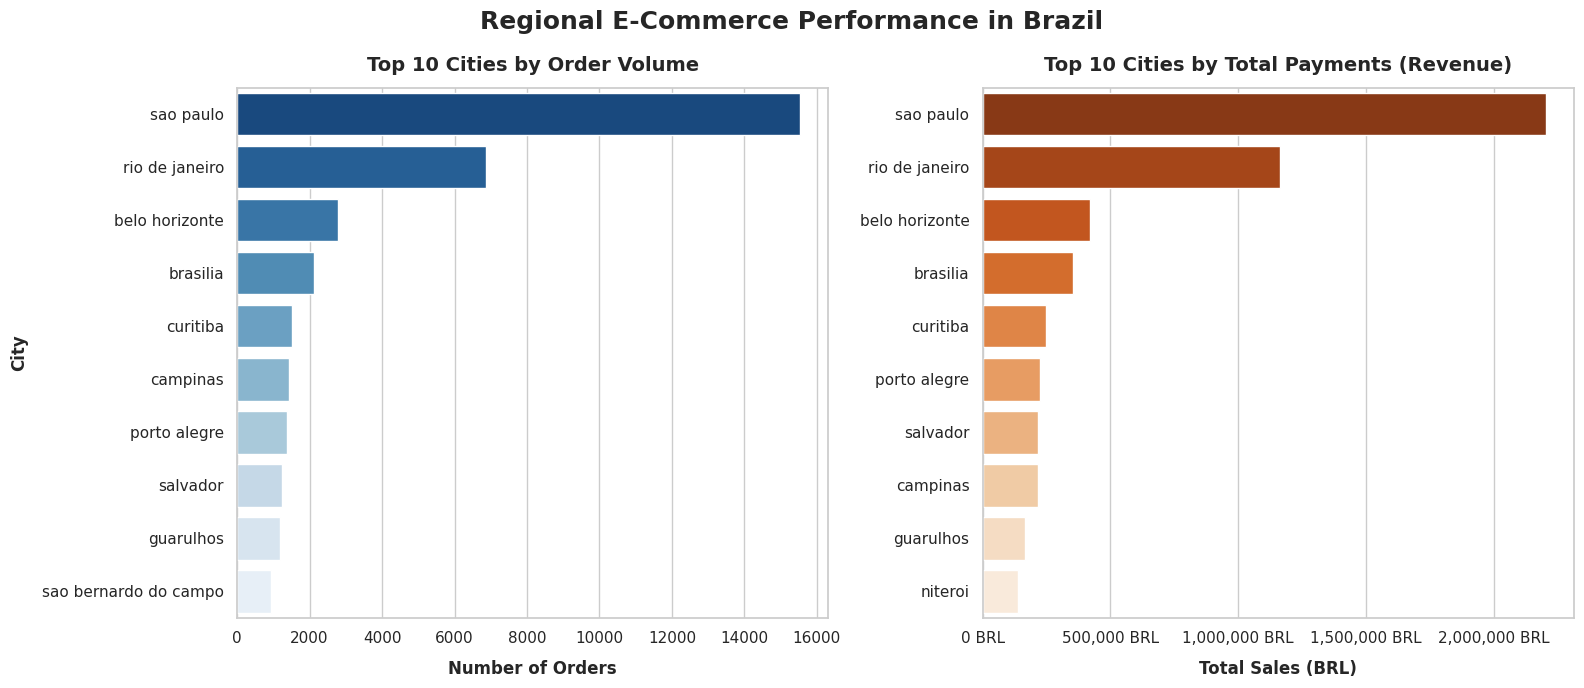

Top 3 Cities by Order Volume:
customer_city
sao paulo         15540
rio de janeiro     6882
belo horizonte     2773
Name: count, dtype: int64

Top 3 Cities by Revenue:
customer_city
sao paulo         2203373.09
rio de janeiro    1161927.36
belo horizonte     421765.12
Name: payment_value, dtype: float64


In [6]:
# Top cities by order volume (using unique orders)
df_unique_orders = df_orders_merged.dropna(subset=['customer_city'])
city_orders = df_unique_orders['customer_city'].value_counts().head(10)

# Top cities by payment revenue
city_revenue = df_unique_orders.groupby('customer_city')['payment_value'].sum().sort_values(ascending=False).head(10)

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(x=city_orders.values, y=city_orders.index, hue=city_orders.index, palette="Blues_r", ax=axes[0], legend=False)
axes[0].set_title('Top 10 Cities by Order Volume', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Number of Orders', fontsize=12, fontweight='bold')
axes[0].set_ylabel('City', fontsize=12, fontweight='bold')

sns.barplot(x=city_revenue.values, y=city_revenue.index, hue=city_revenue.index, palette="Oranges_r", ax=axes[1], legend=False)
axes[1].set_title('Top 10 Cities by Total Payments (Revenue)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Total Sales (BRL)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f} BRL'))

plt.suptitle('Regional E-Commerce Performance in Brazil', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('images/top_cities_orders_revenue.png', dpi=300)
plt.show()

print("Top 3 Cities by Order Volume:")
print(city_orders.head(3))
print("\nTop 3 Cities by Revenue:")
print(city_revenue.head(3))

**Findings:**
*   **São Paulo** is the dominant hub, representing 15,540 orders and generating over 2.2M BRL in transaction value.
*   **Rio de Janeiro** ranks second with 6,882 orders and 1.16M BRL in revenue.
*   **Belo Horizonte** follows in third place with 2,773 orders and 421k BRL.

**Business Implications:**
The Southeast region of Brazil (São Paulo, Rio de Janeiro, and Minas Gerais) represents the vast majority of e-commerce sales. This concentration is driven by higher urban densities, purchasing power, and internet access.

**Recommendations:**
1.  **Fulfillment Strategy:** Locate warehouses and inventory centers in the São Paulo metropolitan area. This allows next-day or same-day deliveries for over 15% of all orders.
2.  **Targeted Geographic Ad Campaigns:** Run geo-fenced marketing campaigns in Rio de Janeiro and Belo Horizonte to capture additional market share where demand is already high.


### **C. When do sales peak? (Seasonality Analysis)**
We extract year-month periods from the purchase timestamps to analyze sales trajectories and seasonal trends.


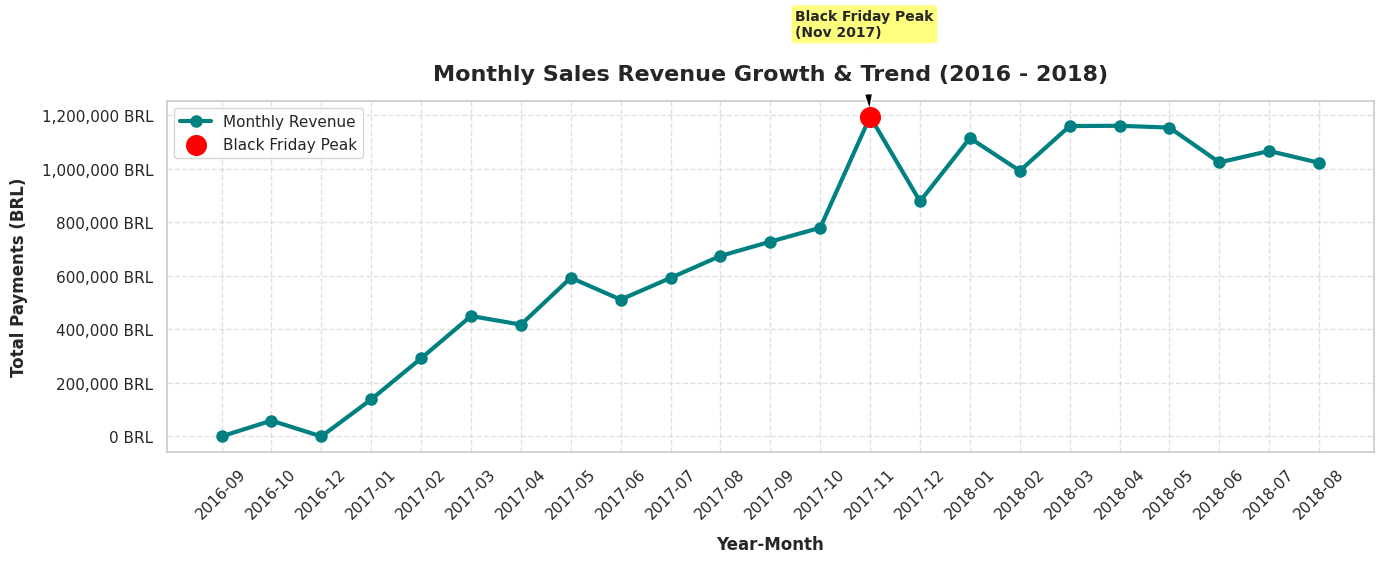

In [7]:
# Filter out late 2018 (September onwards) due to incomplete logging in the raw dataset
df_time_filtered = df_orders_merged[df_orders_merged['order_purchase_timestamp'] < '2018-09-01'].copy()
df_time_filtered['purchase_month_period'] = df_time_filtered['order_purchase_timestamp'].dt.to_period('M')
monthly_sales = df_time_filtered.groupby('purchase_month_period')['payment_value'].sum()

# Monthly Trend Line Chart
plt.figure(figsize=(14, 6))
x_labels = [str(x) for x in monthly_sales.index]
plt.plot(x_labels, monthly_sales.values, marker='o', color='#008080', linewidth=3, markersize=8, label='Monthly Revenue')

# Annotate Black Friday Peak
if '2017-11' in x_labels:
    idx_bf = x_labels.index('2017-11')
    plt.scatter(x_labels[idx_bf], monthly_sales.values[idx_bf], color='red', s=200, zorder=5, label='Black Friday Peak')
    plt.annotate('Black Friday Peak\n(Nov 2017)', 
                 xy=(x_labels[idx_bf], monthly_sales.values[idx_bf]), 
                 xytext=(idx_bf - 1.5, monthly_sales.values[idx_bf] + 300000),
                 arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
                 fontweight='bold', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))

plt.title('Monthly Sales Revenue Growth & Trend (2016 - 2018)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Year-Month', fontsize=12, fontweight='bold')
plt.ylabel('Total Payments (BRL)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f} BRL'))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('images/sales_seasonality_trend.png', dpi=300)
plt.show()

**Findings:**
*   Sales grew significantly from early 2017 (~200k BRL/month) through mid-2018 (~1.1M BRL/month).
*   A major spike occurs in **November 2017**, reaching **1.19M BRL**, representing a nearly 53% increase compared to the prior month. This corresponds to **Black Friday**.
*   After Black Friday, revenue stabilized but remained higher than pre-November levels.

**Business Implications:**
Black Friday is the single most critical sales event of the year for this marketplace. The platform must be prepared for extreme surges in both traffic and order volume during this period.

**Recommendations:**
1.  **Capacity Planning:** RAMP up cloud server capacities and support staff availability in October and November.
2.  **Seller Inventory Preparation:** Send inventory alerts and demand forecasts to major sellers 3 months in advance to prevent stockouts during the Black Friday peak.


### **D. What is the average delivery time?**
We measure delivery speed by calculating the difference between the customer delivery timestamp and the purchase timestamp.


Overall Marketplace Statistics:
 - Average Delivery Time: 12.32 days
 - Median Delivery Time : 10.20 days


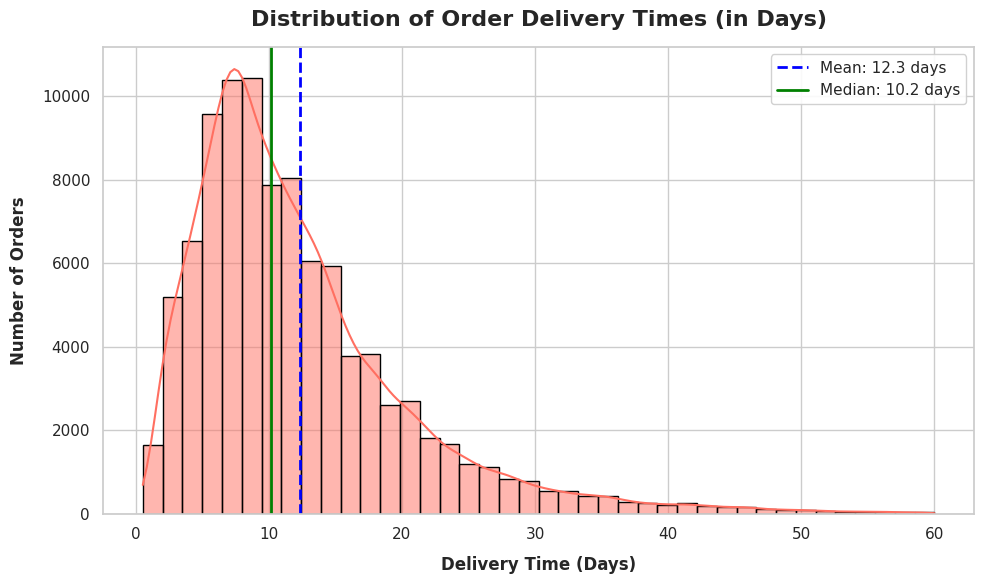

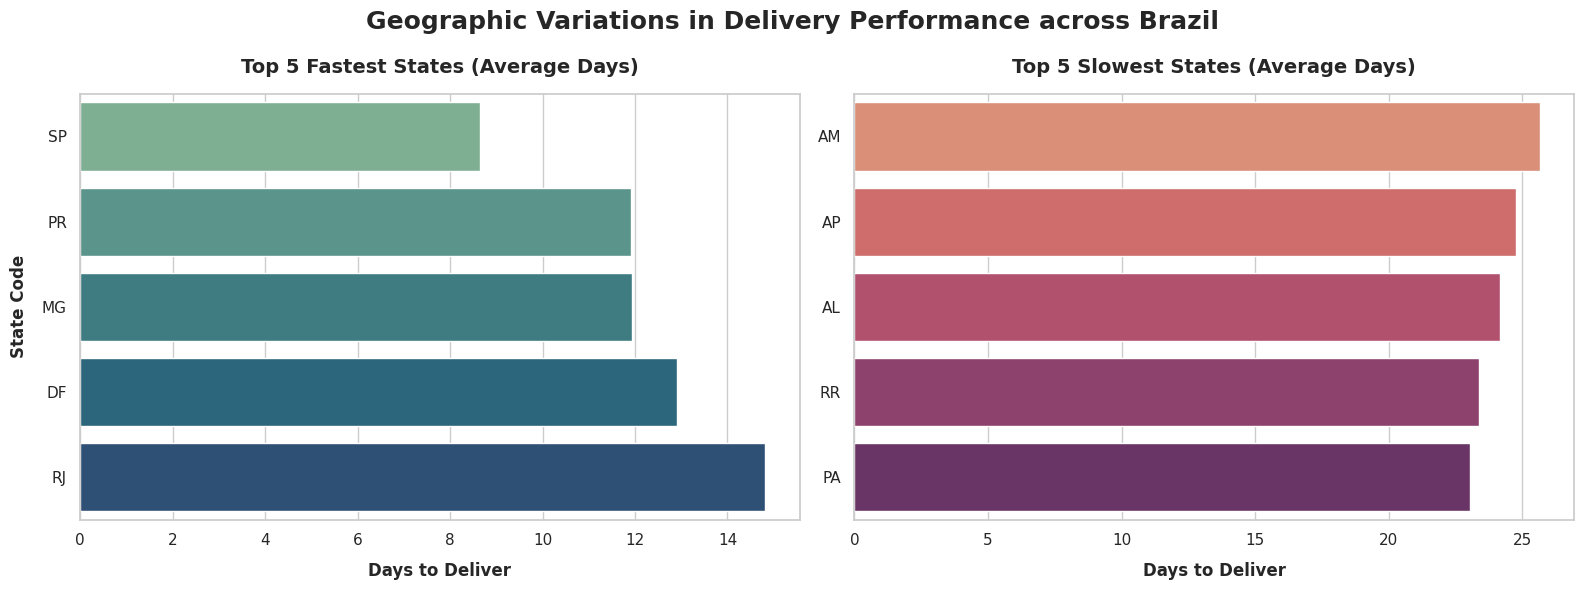

In [8]:
# Calculate delivery time in fractional days
df_delivered = df_orders_merged.dropna(subset=['order_delivered_customer_date', 'order_purchase_timestamp']).copy()
df_delivered['delivery_days'] = (df_delivered['order_delivered_customer_date'] - df_delivered['order_purchase_timestamp']).dt.total_seconds() / 86400.0
# Clean extreme outliers and data entry errors
df_delivered = df_delivered[(df_delivered['delivery_days'] >= 0) & (df_delivered['delivery_days'] <= 60)]

avg_delivery = df_delivered['delivery_days'].mean()
med_delivery = df_delivered['delivery_days'].median()

print(f"Overall Marketplace Statistics:")
print(f" - Average Delivery Time: {avg_delivery:.2f} days")
print(f" - Median Delivery Time : {med_delivery:.2f} days")

# Plot Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_delivered['delivery_days'], bins=40, kde=True, color='#FF6F61', edgecolor='black')
plt.axvline(avg_delivery, color='blue', linestyle='--', linewidth=2, label=f"Mean: {avg_delivery:.1f} days")
plt.axvline(med_delivery, color='green', linestyle='-', linewidth=2, label=f"Median: {med_delivery:.1f} days")
plt.title('Distribution of Order Delivery Times (in Days)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Delivery Time (Days)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Orders', fontsize=12, fontweight='bold')
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.savefig('images/delivery_time_distribution.png', dpi=300)
plt.show()

# Geographic analysis
state_delivery = df_delivered.groupby('customer_state')['delivery_days'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fastest_5 = state_delivery.head(5)
slowest_5 = state_delivery.tail(5).sort_values(ascending=False)

sns.barplot(x=fastest_5.values, y=fastest_5.index, hue=fastest_5.index, palette="crest", ax=axes[0], legend=False)
axes[0].set_title('Top 5 Fastest States (Average Days)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Days to Deliver', fontsize=12, fontweight='bold')
axes[0].set_ylabel('State Code', fontsize=12, fontweight='bold')

sns.barplot(x=slowest_5.values, y=slowest_5.index, hue=slowest_5.index, palette="flare", ax=axes[1], legend=False)
axes[1].set_title('Top 5 Slowest States (Average Days)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Days to Deliver', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Geographic Variations in Delivery Performance across Brazil', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('images/delivery_time_by_state.png', dpi=300)
plt.show()

**Findings:**
*   The average delivery time across Brazil is **12.3 days** (median: 10.2 days). The distribution has a long tail, extending up to 45+ days.
*   **Geographic Divide:** The fastest states are in the south/southeast: **São Paulo (SP) averages 8.7 days**, Paraná (PR) and Minas Gerais (MG) average ~11.9 days.
*   The slowest states are in the remote North/Northeast: **Amazonas (AM) averages 25.6 days**, Amapá (AP) averages 24.8 days, and Alagoas (AL) averages 24.1 days.

**Business Implications:**
Waiting 20-25 days for e-commerce deliveries reduces customer satisfaction in the North and Northeast, which limits market growth in those regions.

**Recommendations:**
1.  **Decentralized Logistics:** Partner with regional third-party logistics (3PL) providers and lease regional distribution hubs in the north-northeast to store high-demand inventory.
2.  **Dynamic Freight Pricing:** Transparently display delivery options at checkout with premium fast-shipping services for customers who want to bypass regional delays.


### **E. Do customers make repeat orders?**
We evaluate customer loyalty by grouping order entries by their unique customer ID (`customer_unique_id`) and assessing the count of orders.


Marketplace Loyalty Metrics:
 - Total Unique Customers : 96,096
 - Repeat Buyers (>=2 orders): 2,997
 - Repeat Purchase Rate     : 3.12%


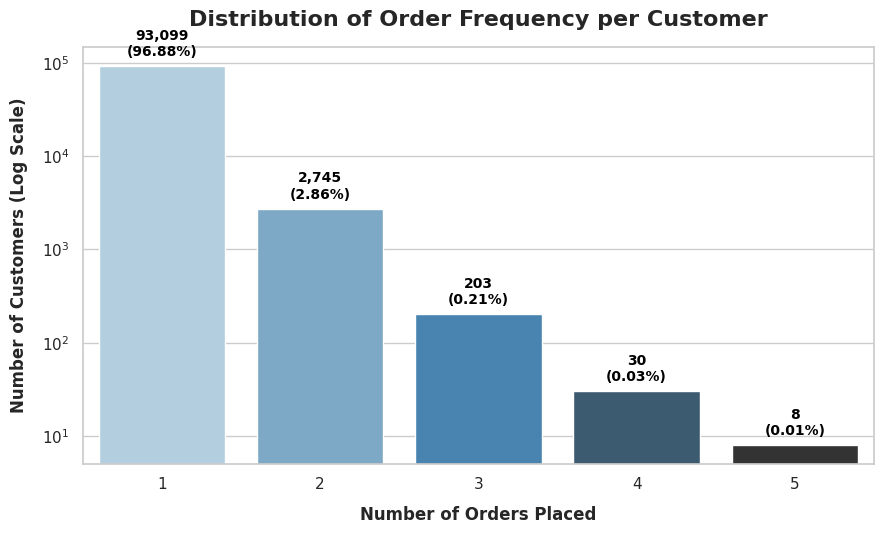

In [9]:
# Evaluate customer order counts
order_counts = df_orders_merged.groupby('customer_unique_id')['order_id'].nunique()
total_customers = len(order_counts)
repeat_customers = (order_counts > 1).sum()
repeat_rate = (repeat_customers / total_customers) * 100

print(f"Marketplace Loyalty Metrics:")
print(f" - Total Unique Customers : {total_customers:,}")
print(f" - Repeat Buyers (>=2 orders): {repeat_customers:,}")
print(f" - Repeat Purchase Rate     : {repeat_rate:.2f}%")

# Order frequency distribution
freq_dist = order_counts.value_counts().head(5)

plt.figure(figsize=(9, 5.5))
ax = sns.barplot(x=freq_dist.index, y=freq_dist.values, hue=freq_dist.index, palette="Blues_d", legend=False)
plt.title('Distribution of Order Frequency per Customer', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Orders Placed', fontsize=12, fontweight='bold')
plt.ylabel('Number of Customers (Log Scale)', fontsize=12, fontweight='bold')
plt.yscale('log') # Applied log scale due to heavy skewness

for p in ax.patches:
    val = p.get_height()
    pct = (val / total_customers) * 100
    ax.annotate(f'{val:,.0f}\n({pct:.2f}%)', 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', 
                fontsize=10, color='black', 
                xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.savefig('images/customer_order_frequency.png', dpi=300)
plt.show()

**Findings:**
*   The repeat purchase rate is very low at **3.12%**. Out of 96,096 unique customers, only 2,997 placed more than one order.
*   **96.88%** of customers placed exactly 1 order during the 2-year period.
*   Very few customers placed 3 or more orders (241 customers total).

**Business Implications:**
The business model is heavily dependent on continuous customer acquisition. This is unsustainable in the long term, as customer acquisition costs (CAC) typically rise over time. Boosting customer lifetime value (LTV) is crucial for profitability.

**Recommendations:**
1.  **Post-Purchase Loyalty Funnels:** Send automated post-purchase coupon codes (e.g., "15% off your next purchase") within 7 days of delivery.
2.  **Loyalty Program:** Introduce a membership tier (similar to Amazon Prime) that offers free shipping, incentivizing consumers to buy exclusively from Olist.
3.  **Cross-Category Marketing:** Use purchase histories to send personalized recommendations (e.g., suggesting bed sheets to someone who bought pillows).


## 6. Advanced Analysis & Insights

We explore three additional insights to understand the factors driving e-commerce performance:
1.  **Payment Method Breakdown**: How do customers finance their purchases?
2.  **Delivery Speed vs. Customer Review Scores**: How do delivery delays affect customer ratings?
3.  **Correlation Heatmap**: Analyzing relationships between transaction metrics.


### **Insight 1: Payment Method Breakdown**
Analyzing the transaction share of different payment methods used on the platform.


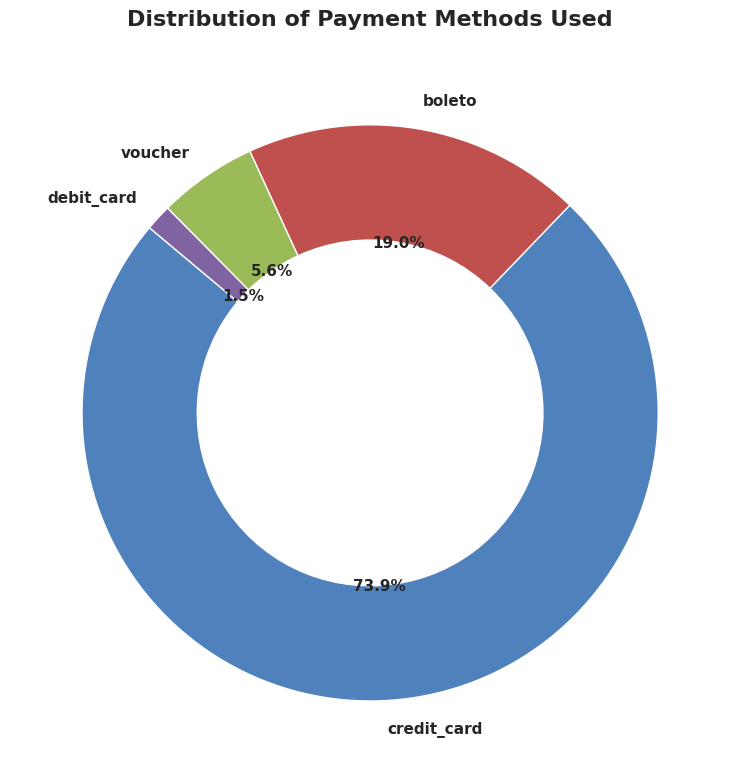

Payment counts:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
Name: count, dtype: int64


In [10]:
# Payment method counts
payment_counts = df_payments['payment_type'].value_counts()
# Exclude small/undefined entries for clarity
payment_counts = payment_counts[payment_counts.index != 'not_defined']

plt.figure(figsize=(8, 8))
colors = ['#4F81BD', '#C0504D', '#9BBB59', '#8064A2', '#4BACC6']
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, textprops={'fontweight':'bold', 'fontsize':11},
        wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title('Distribution of Payment Methods Used', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('images/payment_methods_distribution.png', dpi=300)
plt.show()

print("Payment counts:")
print(payment_counts)

**Findings:**
*   **Credit Cards** are the dominant payment method, used in **73.9%** of transactions.
*   **Boleto Bancário** (a standard cash receipt payment system in Brazil) ranks second at **19.0%**.
*   Vouchers (5.6%) and Debit Cards (1.5%) represent small shares.

**Business Implications:**
Credit card integration is critical. Installment payment options (offered by credit cards in Brazil) are likely a key driver for higher-value orders.

**Recommendations:**
1.  **Installment Plans:** Ensure installment plans are clearly presented at checkout, especially for high-ticket items.
2.  **Optimize Boleto Processes:** Since boletos take 1-2 business days to clear, automate approval checks to prevent shipping delays.


### **Insight 2: How Delivery Speed Affects Customer Reviews**
We analyze the relationship between delivery times and customer satisfaction ratings.


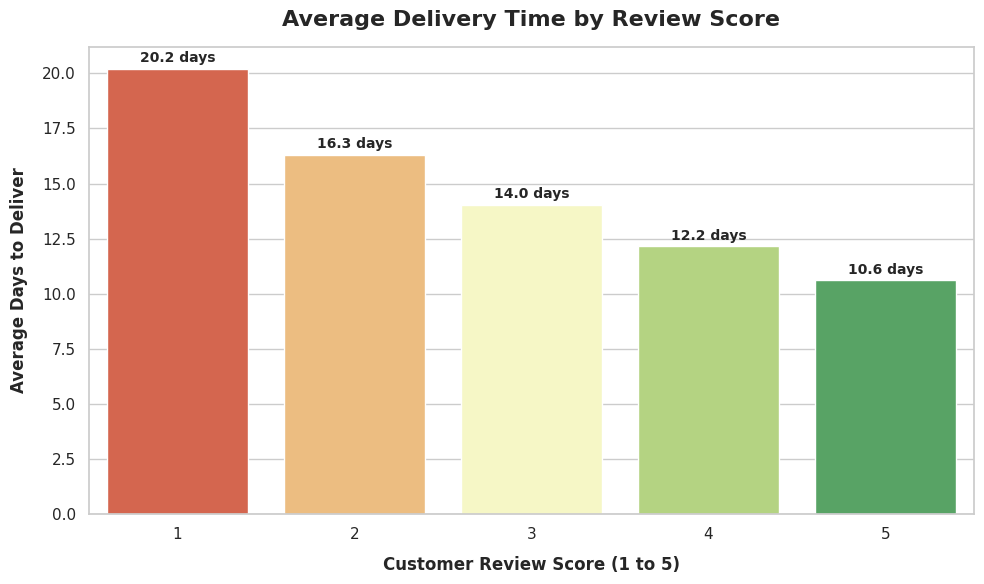

Average delivery days per review score group:
review_score_int
1    20.197268
2    16.306039
3    14.024906
4    12.154007
5    10.612184
Name: delivery_days, dtype: float64


In [11]:
# Merge reviews with delivery times
df_reviews_delivery = pd.merge(
    df_orders_merged[['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date']], 
    df_reviews_cleaned, 
    on='order_id'
)
df_reviews_delivery['delivery_days'] = (
    df_reviews_delivery['order_delivered_customer_date'] - df_reviews_delivery['order_purchase_timestamp']
).dt.total_seconds() / 86400.0
# Clean anomalies and outliers
df_reviews_delivery = df_reviews_delivery[(df_reviews_delivery['delivery_days'] >= 0) & (df_reviews_delivery['delivery_days'] <= 60)]

# Round review scores to the nearest integer
df_reviews_delivery['review_score_int'] = df_reviews_delivery['review_score'].round().astype(int)
avg_delivery_by_score = df_reviews_delivery.groupby('review_score_int')['delivery_days'].mean()

plt.figure(figsize=(10, 6))
colors_div = sns.color_palette("RdYlGn", 5)
sns.barplot(x=avg_delivery_by_score.index, y=avg_delivery_by_score.values, hue=avg_delivery_by_score.index, palette=colors_div, legend=False)
plt.title('Average Delivery Time by Review Score', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Customer Review Score (1 to 5)', fontsize=12, fontweight='bold')
plt.ylabel('Average Days to Deliver', fontsize=12, fontweight='bold')

for i, val in enumerate(avg_delivery_by_score.values):
    plt.text(i, val + 0.3, f"{val:.1f} days", ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('images/review_score_vs_delivery_time.png', dpi=300)
plt.show()

print("Average delivery days per review score group:")
print(avg_delivery_by_score)

**Findings:**
*   There is a clear link between delivery times and review scores.
*   Orders with **5-star reviews average 10.6 days** to deliver.
*   In contrast, orders with **1-star reviews average 20.2 days**—nearly double the delivery time.
*   The transition from a 5-star to a 1-star rating follows a consistent increase in delivery delays.

**Business Implications:**
Delivery speed is a key driver of customer satisfaction. Delayed deliveries are a primary cause of low ratings, which can hurt brand reputation and customer lifetime value.

**Recommendations:**
1.  **Proactive Delay Communication:** If an order is delayed past its estimated delivery date, send automated email alerts with delivery updates and store credit to mitigate negative reviews.
2.  **Seller SLAs:** Implement strict penalties for sellers who take more than 48 hours to hand packages over to carriers.


### **Insight 3: Correlation Matrix of Key E-Commerce Metrics**
We analyze the linear relationships between numeric variables (Price, Freight, Total Payment, Delivery Days, Review Score).


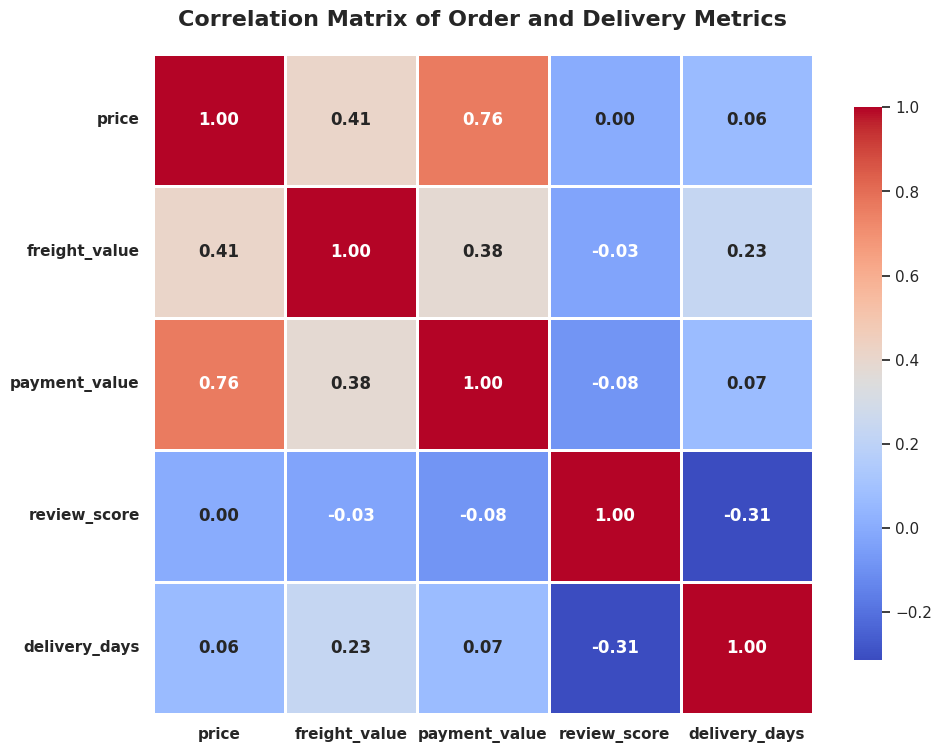

In [12]:
# Create subset of metrics
df_corr_data = df_full[['price', 'freight_value', 'payment_value', 'review_score']].copy()
df_corr_data['delivery_days'] = (
    df_full['order_delivered_customer_date'] - df_full['order_purchase_timestamp']
).dt.total_seconds() / 86400.0
# Clean anomalies
df_corr_data = df_corr_data[(df_corr_data['delivery_days'] >= 0) & (df_corr_data['delivery_days'] <= 60)].dropna()

corr_matrix = df_corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1, 
            annot_kws={'weight': 'bold', 'size': 12}, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Order and Delivery Metrics', fontsize=16, fontweight='bold', pad=20)
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold', rotation=0)
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=300)
plt.show()

**Findings:**
*   **Delivery Days & Review Score (-0.31):** Shows a moderate negative correlation. As delivery days increase, review scores decrease. This is the strongest relationship with customer feedback in this dataset.
*   **Price & Freight Value (0.41):** Shows a moderate positive correlation. Heavier or more expensive items often carry higher shipping fees.
*   **Price & Payment Value (0.76):** A strong positive correlation, showing that item prices are the primary driver of total payment value.

**Business Implications:**
Logistics performance (delivery speed) has a larger impact on customer satisfaction than product price. Customers are sensitive to delivery times.

**Recommendations:**
1.  **Prioritize Shipping Logistics:** Shipping speed should be monitored as a key performance indicator (KPI).
2.  **Optimized Freight Rates:** Since freight costs correlate with price, subsidizing freight costs for high-value items can help increase average order value.


## 7. Conclusions and Strategic Recommendations

This analysis highlights key areas for growth and optimization across Olist's operations.

### **1. Marketing Strategy: Focus on High-Performing Categories**
*   **Focus Areas:** Allocate marketing budgets to top categories: **Health & Beauty**, **Watches & Gifts**, and **Bed/Bath/Table**.
*   **Action:** Build targeted seasonal campaigns for these categories to drive growth and capture high-value sales.

### **2. Logistics Strategy: Address Regional Bottlenecks**
*   **Focus Areas:** Solve delivery delays in the North and Northeast regions, where shipping times average over 24 days.
*   **Action:** Partner with regional warehouses (micro-fulfillment centers) to store high-demand items closer to regional buyers, aiming to reduce delivery times to under 12 days.

### **3. Customer Retention Strategy: Build Brand Loyalty**
*   **Focus Areas:** Improve the platform's low repeat purchase rate of **3.12%**.
*   **Action:** Set up automated post-purchase email flows with discounts for second orders, and launch a loyalty program to build repeat business.

### **4. Operations Strategy: Manage Seller Shipping Speed**
*   **Focus Areas:** Ensure fast order processing times, as delivery delays lead directly to lower customer reviews.
*   **Action:** Establish operational guidelines (SLAs) for sellers, requiring packages to be handed to carriers within 48 hours. Promote sellers who maintain fast processing times.
